# 3.1 Molecular Dynamics of Lennard-Jones Clusters

<!-- One H1 per notebook ("# <number> <Title>"): it sets the sidebar entry,
     breadcrumb, browser tab, and search result. The branded banner below is
     generated by the shared `ecp` package. -->

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume III — Molecular Dynamics",
    number="3.1",
    title="Molecular Dynamics of Lennard-Jones Clusters",
    blurb="Newton's equations in time: a velocity-Verlet integrator that conserves "
    "energy where Euler explodes, a thermostat that holds an argon cluster at 20 K, "
    "the radial distribution function that reads off its structure, and the "
    "melting that smears it away.",
    difficulty="intermediate",
    estimate="90–120 min",
    source="FS 2023 · Lecture 9 (molecular dynamics)",
)

<ECP header: 2834 chars of HTML>

## Notebook overview

In Volume II we found the *static* structure of a Lennard-Jones cluster by sliding
downhill to a minimum. Here we let it *move*. Integrating Newton's equations in
time turns the same potential into a trajectory: atoms vibrate about their lattice
sites, the cluster holds its shape at low temperature and falls apart at high
temperature, and the time-averaged structure becomes thermodynamics. This is the
molecular-dynamics half of the cluster story, and the route to nearly everything
measurable in a liquid or solid.

This is the exercise from Lecture 9, and we follow it. The course thermalized a
38-atom argon cluster in **CP2K**, in the canonical ensemble with a thermostat,
then ran a microcanonical production simulation to extract the **radial
distribution function** $g(r)$. We show those input decks and reproduce the runs
in Python, because CP2K's classical engine here is again just the Lennard-Jones
potential. We build the **velocity-Verlet** integrator, see why it conserves
energy where a naive scheme does not, control temperature with a velocity-rescaling
**thermostat**, compute $g(r)$ from the trajectory, and watch the cluster melt.

> **Provenance.** This notebook develops **Lecture 9** of the course (molecular
> dynamics, ensembles, time integration, and the radial distribution function).
> The original ran CP2K (the `thermalization_38.inp` and `production_38.inp` decks
> shown in Exercise 1) on the Euler cluster; since the force field is exactly the
> Lennard-Jones potential, the dynamics are reproduced here in Python, and the
> analysis ($g(r)$, energy conservation, temperature) mirrors the original. The
> full course credit is in the footer.

> **Reading a validation.** Each exercise closes with a check against something
> independent: a conservation law, the equipartition theorem, the known
> nearest-neighbour spacing. A ✗ flags a mismatch to track down, not a verdict; a
> ✓ is strong evidence, not proof.

> **Units and scope.** We use reduced Lennard-Jones units, energies in
> $\varepsilon$, lengths in $\sigma$, masses in $m$, so $\varepsilon=\sigma=m=1$
> and $k_B=1$; temperature is then $T^\*=k_BT/\varepsilon$. The deck's argon values
> $\varepsilon=119.8\,k_B\,$K and $\sigma=3.405\,$Å set the scale, so its target of
> $20\,$K is $T^\*=20/119.8\approx0.167$. For methods see Allen & Tildesley
> {cite}`allen-tildesley` and Frenkel & Smit {cite}`frenkel-smit`; the founding
> study is Verlet {cite}`verlet1967`.

## Theory in brief

### Equations of motion

Each atom obeys Newton's second law with the Lennard-Jones force,

```{math}
:label: eq-eom
m\,\ddot{\mathbf r}_i = \mathbf F_i = -\nabla_i E, \qquad
E = \sum_{i<j} 4\varepsilon\!\left[\left(\tfrac{\sigma}{r_{ij}}\right)^{12}-\left(\tfrac{\sigma}{r_{ij}}\right)^{6}\right].
```

In reduced units $m=1$, so the acceleration *is* the force. Integrated forward in
time from initial positions and velocities, {eq}`eq-eom` is a deterministic
trajectory, and the energy $E+\tfrac12\sum_i m\dot{\mathbf r}_i^2$ is conserved.

### Time integration: velocity Verlet

We advance the trajectory with the **velocity-Verlet** algorithm, the workhorse of
molecular dynamics:

```{math}
:label: eq-verlet
\mathbf r(t+\Delta t) = \mathbf r(t) + \mathbf v(t)\,\Delta t + \tfrac12\mathbf a(t)\,\Delta t^2,
\qquad
\mathbf v(t+\Delta t) = \mathbf v(t) + \tfrac12\big[\mathbf a(t)+\mathbf a(t+\Delta t)\big]\Delta t.
```

It is *symplectic* and time-reversible, which is why it conserves energy over long
runs with no systematic drift, where a naive forward-Euler step
($\mathbf r\!\to\!\mathbf r+\mathbf v\Delta t$, $\mathbf v\!\to\!\mathbf v+\mathbf a\Delta t$)
pumps energy in and diverges. The price is a timestep $\Delta t$ small enough to
resolve the fastest vibration.

### Ensembles and temperature

An isolated trajectory samples the **microcanonical** ($NVE$) ensemble: fixed
particle number, volume, and energy. To fix *temperature* instead, the
**canonical** ($NVT$) ensemble couples the system to a heat bath through a
**thermostat**. The instantaneous temperature comes from the kinetic energy by
equipartition, with $3N-3$ degrees of freedom after removing the centre-of-mass
motion,

```{math}
:label: eq-temperature
\tfrac12\textstyle\sum_i m\,\mathbf v_i^2 = \tfrac{1}{2}(3N-3)\,k_B T
\;\;\Longrightarrow\;\;
T = \frac{\sum_i m\,\mathbf v_i^2}{(3N-3)\,k_B}.
```

The simplest thermostat rescales every velocity by $\sqrt{T_{\rm target}/T}$; the
course used the gentler **canonical velocity rescaling** (CSVR) {cite}`bussi2007`,
which adds the right fluctuations, but the rescaling idea is the same.

### Structure: the radial distribution function

The **radial distribution function** $g(r)$ is the probability of finding a pair of
atoms a distance $r$ apart, relative to an ideal gas of the same density:

```{math}
:label: eq-gr
g(r) = \frac{1}{\rho\,N}\Big\langle \sum_{i\neq j}\delta(r-r_{ij})\Big\rangle \Big/ 4\pi r^2 .
```

Its peaks sit at the neighbour-shell distances, so a sharp first peak at the
nearest-neighbour spacing $r_{\min}=2^{1/6}\sigma$ signals a solid, and the smooth
decay of a liquid signals lost long-range order. It is the simulation's direct
bridge to x-ray and neutron scattering.

---
## Setup

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

from ecp import validate

rng = np.random.default_rng(0)
RMIN = 2.0 ** (1.0 / 6.0)            # Lennard-Jones nearest-neighbour separation
SIGMA_AR, EPS_AR_K = 3.405, 119.8    # argon sigma [Å] and epsilon [K], from the deck
T_STAR_20K = 20.0 / EPS_AR_K         # reduced temperature of the deck's 20 K target
INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"


def lj_forces(x):
    """Lennard-Jones potential energy and forces (-grad E) for `x` of shape (N, 3)."""
    x = np.asarray(x).reshape(-1, 3)
    d = x[:, None, :] - x[None, :, :]
    r2 = np.sum(d * d, axis=2)
    np.fill_diagonal(r2, np.inf)
    inv6 = r2 ** -3
    inv12 = inv6 * inv6
    energy = np.sum(4.0 * (inv12 - inv6)) / 2.0
    coeff = 4.0 * (-12.0 * inv12 + 6.0 * inv6) / r2
    grad = np.sum(coeff[:, :, None] * d, axis=1)
    return energy, -grad


def kinetic(v):
    return 0.5 * np.sum(v * v)


def temperature(v):
    """Instantaneous temperature from equipartition, Eq. (eq-temperature)."""
    return 2.0 * kinetic(v) / (3 * len(v) - 3)


def data_file(name):
    """Locate a shipped data file from the repo root (CI) or the notebook dir (Colab)."""
    for base in ("data", os.path.join("notebooks", "03-molecular-dynamics", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)


def read_xyz(name):
    """Read an .xyz file, returning coordinates of shape (N, 3) in file units (Å)."""
    lines = open(data_file(name)).read().splitlines()
    n = int(lines[0].split()[0])
    return np.array([[float(v) for v in ln.split()[1:4]] for ln in lines[2:2 + n]])


# The course's relaxed 38-atom argon cluster, exactly as the MD decks read it in
# (data/38atoms.xyz, in Å). We convert to reduced units by dividing by σ and centre
# it; its Lennard-Jones energy is the LJ38 global minimum, −173.928 ε (Exercise 2.1).
cluster_A = read_xyz("38atoms.xyz")
cluster = (cluster_A - cluster_A.mean(0)) / SIGMA_AR
N = len(cluster)


def maxwell_velocities(T_star, seed_rng):
    """Draw centre-of-mass-free velocities at temperature T_star (reduced units)."""
    v = seed_rng.normal(size=(N, 3))
    v -= v.mean(0)
    v *= np.sqrt(T_star / temperature(v))
    return v

## Exercise 1 — Velocity Verlet and the microcanonical ensemble

Here is the engine of the original exercise. The course thermalized the cluster
with CP2K, whose `thermalization_38.inp` deck sets `RUN_TYPE MD`, `ENSEMBLE NVT`,
`TIMESTEP 0.5` fs, `TEMPERATURE 20.0` K, and a `CSVR` thermostat, on the same
`METHOD Fist` Lennard-Jones force field as before:

```text
&MD
  ENSEMBLE NVT
  STEPS 10000
  TIMESTEP 0.5            ! femtoseconds
  TEMPERATURE 20.0        ! kelvin
  &THERMOSTAT
    TYPE CSVR             ! canonical sampling through velocity rescaling
  &END THERMOSTAT
&END MD
```

The decks ship with this notebook: {download}`thermalization_38.inp <data/thermalization_38.inp>`
(canonical, with thermostat) and {download}`production_38.inp <data/production_38.inp>`
(microcanonical, `ENSEMBLE NVE`, no thermostat). We reproduce them by integrating
{eq}`eq-eom` with velocity Verlet {eq}`eq-verlet`. With no thermostat the run is
microcanonical, so the conserved quantity to watch is the *total* energy.

**Part a)** Implement `run_md` (velocity Verlet, optional velocity-rescaling
thermostat). **Part b)** Run the cluster in $NVE$ from velocities drawn at
$T^\*=0.1$ and confirm the total energy is conserved.

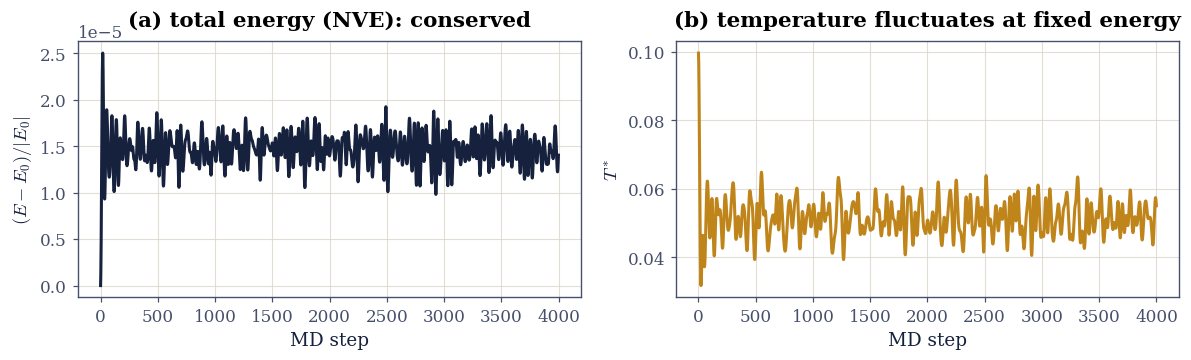

In [3]:
# (solution hidden on the public site)


### Validation 1 — energy conservation in NVE

A correct microcanonical trajectory conserves the total energy: its relative
drift over the run must be tiny, the molecular-dynamics equivalent of "did I
integrate it right?".

In [4]:
validate.conserved(E_nve, "velocity-Verlet NVE run conserves total energy", rel_drift=1e-3)

✓  velocity-Verlet NVE run conserves total energy   [max relative drift = 2.50255e-05 (limit 0.001)]


True

## Exercise 2 — Why velocity Verlet: the energy drift of Euler

The Verlet scheme is not the obvious one. The naive forward-Euler step,
$\mathbf r\to\mathbf r+\mathbf v\Delta t$ then $\mathbf v\to\mathbf v+\mathbf a\Delta t$,
looks just as reasonable but is *not* symplectic, and it pumps energy into the
system until the trajectory is meaningless. Run both integrators from the same
start and the difference is stark: Verlet's energy stays flat, Euler's climbs
without bound. The drift also worsens with the timestep, which is why the course
spent an assignment "converging the time steps".

**Part a)** Integrate the same initial condition with Euler and with Verlet.
**Part b)** Confirm Euler's energy drift dwarfs Verlet's.

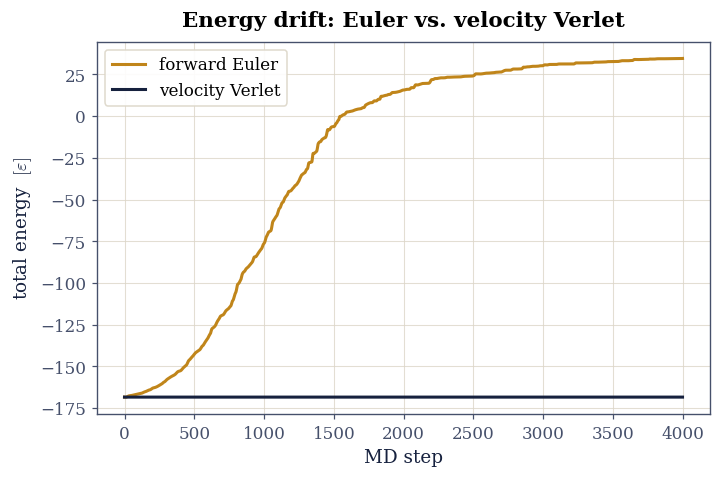

In [5]:
# (solution hidden on the public site)


### Validation 2 — Euler drifts, Verlet does not

At the same timestep the forward-Euler energy drift must exceed the Verlet drift
by orders of magnitude, the quantitative reason molecular dynamics uses symplectic
integrators.

In [6]:
validate.check(
    drift_euler > 100 * drift_verlet,
    "forward Euler drifts far more than velocity Verlet at equal timestep",
    f"Euler drift = {drift_euler:.1e}, Verlet drift = {drift_verlet:.1e}",
)

✓  forward Euler drifts far more than velocity Verlet at equal timestep   [Euler drift = 1.2e+00, Verlet drift = 2.2e-05]


True

## Exercise 3 — Temperature and thermalization (the canonical ensemble)

The microcanonical run holds energy fixed and lets temperature fluctuate. To
prepare the cluster at a *chosen* temperature, as the course did before measuring
anything, we couple it to a thermostat. The simplest version rescales every
velocity by $\sqrt{T_{\rm target}/T}$ at intervals, nudging the kinetic energy
toward equipartition {eq}`eq-temperature`. Starting the cluster cold and
thermostatting to the deck's target $T^\*=20/119.8\approx0.167$, the temperature
climbs and then settles, fluctuating about the target.

**Part a)** Thermalize the cluster to $T^\*=0.167$ with the velocity-rescaling
thermostat. **Part b)** Confirm the time-averaged temperature equals the target.

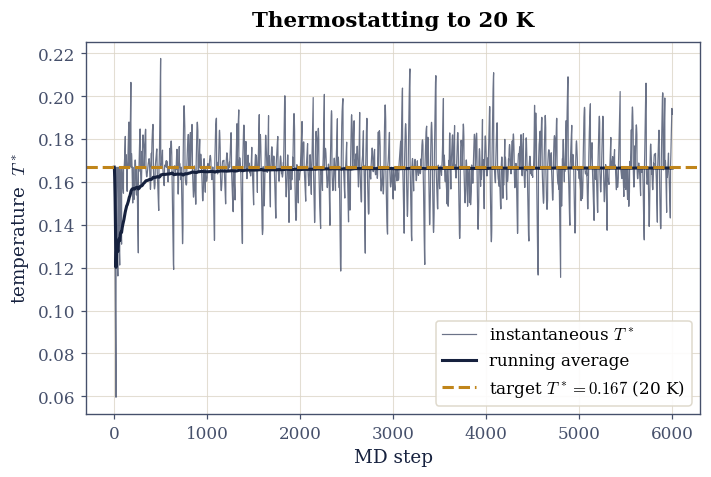

In [7]:
# (solution hidden on the public site)


### Validation 3 — the thermostat reaches the target temperature

After equilibration the time-averaged temperature must equal the thermostat
target $T^\*=0.167$, the defining property of a canonical simulation.

In [8]:
validate.close(T_mean, T_STAR_20K, "thermostat holds the cluster at the target temperature", rtol=0.15)

✓  thermostat holds the cluster at the target temperature   [got 0.166855 vs expected 0.166945 (rtol=0.15)]


True

## Exercise 4 — The radial distribution function

With the cluster thermalized we measure its structure. The radial distribution
function $g(r)$ {eq}`eq-gr` is a histogram of pairwise distances, normalised by the
$4\pi r^2$ shell volume, accumulated over a microcanonical production trajectory
(thermalize first, then run $NVE$ and sample, exactly the canonical-then-
microcanonical workflow of the two decks). For the cold solid cluster $g(r)$ shows
a sharp first peak at the nearest-neighbour spacing $r_{\min}=2^{1/6}\sigma$ and
further peaks at the next shells, the fingerprint of an ordered structure.
Integrating that first peak (Assignment 8) gives the **coordination number**, the
average count of nearest neighbours, well below the bulk fcc value of 12 for a
cluster where most atoms sit on the surface.

**Part a)** Implement `radial_distribution(frames)`. **Part b)** Thermalize cold,
run an $NVE$ production trajectory, and locate the first peak of $g(r)$.
**Part c)** Read off the coordination number.

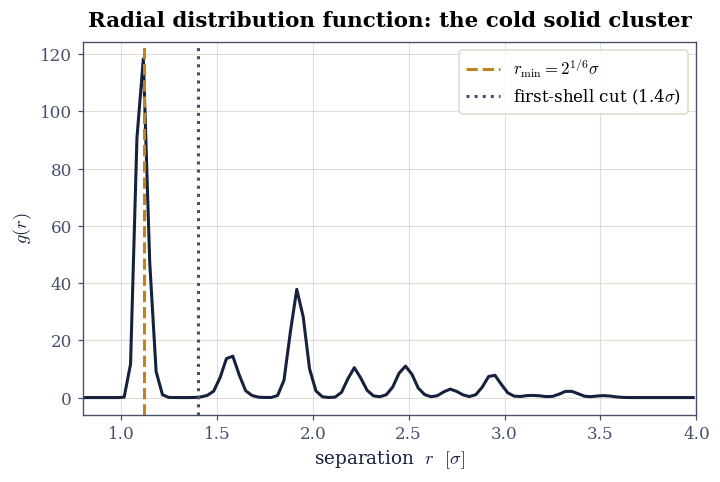

average coordination number = 7.6  (bulk fcc = 12; lower here, surface atoms)


In [9]:
# (solution hidden on the public site)


### Validation 4 — the first peak is the nearest-neighbour shell

The first peak of $g(r)$ must sit at the Lennard-Jones nearest-neighbour distance
$r_{\min}=2^{1/6}\approx1.122$, where the pair potential is minimised.

In [10]:
validate.close(first_peak, RMIN, "g(r) first peak sits at the nearest-neighbour distance", rtol=0.06)

✓  g(r) first peak sits at the nearest-neighbour distance   [got 1.11667 vs expected 1.12246 (rtol=0.06)]


True

## Exercise 5 — Melting the cluster

Raise the temperature and the cluster comes apart. Where the cold solid keeps
atoms pinned near their lattice sites, giving a sharp $g(r)$, a hot cluster has
enough kinetic energy for atoms to diffuse past one another: the first peak
broadens and the further shells wash out, the signature of a liquid (or, for a
finite cluster, of melting and evaporation). The animation shows the hot cluster
in motion, something no static structure can convey; we validate the *physics* of
that motion, that its $g(r)$ is measurably less ordered than the cold solid's.

**Part a)** Run a cold and a hot production trajectory and compare their $g(r)$.
**Part b)** Animate the hot, melting cluster.

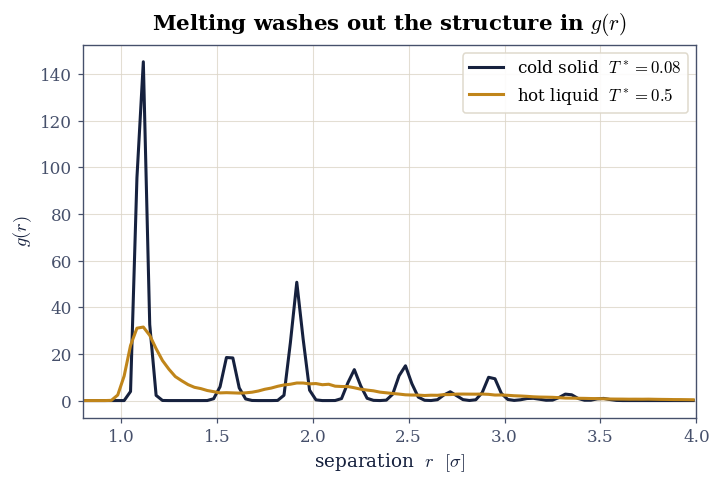

In [11]:
# (solution hidden on the public site)


In [12]:
# (solution hidden on the public site)


### Validation 5 — the hot cluster is less ordered

Melting must register in $g(r)$: the first peak of the hot trajectory is markedly
lower (broader) than the cold solid's, because diffusion has blurred the
nearest-neighbour shell.

In [13]:
validate.check(
    peak_hot < 0.6 * peak_cold,
    "the hot liquid g(r) is markedly less ordered than the cold solid",
    f"first-peak height: cold {peak_cold:.1f} vs hot {peak_hot:.1f}",
)

✓  the hot liquid g(r) is markedly less ordered than the cold solid   [first-peak height: cold 145.2 vs hot 31.5]


True

## Going further

- **Real thermostats.** The velocity rescaling here is crude; the course's CSVR
  {cite}`bussi2007`, and Nosé-Hoover, sample the canonical ensemble *correctly*,
  with the right energy fluctuations rather than a hard rescale.
- **The caloric curve.** Average the potential energy over thermalized runs across
  a temperature grid; the kink where it rises steeply locates the cluster's melting
  temperature, and the latent heat of the transition.
- **Diffusion.** The mean-squared displacement $\langle|\mathbf r(t)-\mathbf r(0)|^2\rangle$
  grows linearly in a liquid; its slope is the diffusion coefficient, zero in the
  solid and finite above melting.
- **Bulk and periodic boundaries.** The course also ran a bulk crystal with
  periodic boundaries (`production_bulk.inp`); with the minimum-image convention
  $g(r)$ extends to many shells and yields the equation of state.
- **Enhanced sampling.** Replica exchange (Lecture 12) runs many temperatures at
  once and swaps between them, sampling melting and rare events far more
  efficiently than a single trajectory.

### References

```{bibliography}
:filter: docname in docnames
```

In [14]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>